# CLustering Techniques #

In [7]:
# Data Handling and Manipulation
import pandas as pd
import numpy as np

# Data Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

# Model Selection and Evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.mixture import GaussianMixture

# Machine Learning Models
from sklearn.cluster import KMeans
# from sklearn_extra.cluster import KMedoids  # Cannot install scikit-learn-extra with python 3.12, 3.13

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set the default style for visualization
sns.set_theme(style = "white", palette = "colorblind")

# Increase font size of all Seaborn plot elements
sns.set(font_scale = 1.25)

Dataset: Student_Info.csv

This dataset contains anonymized student-level data capturing key academic, demographic, and behavioral features. It's crafted to help users understand the impact of various factors—such as study time, family background, and extracurricular activities—on student performance outcomes.

Objective
* Explore the impact of studying hours, previous scores, extracurricular activities, sleep hours, and sample question papers on student performance.
* Implement various clustering methods to reveal patterns on student performance. Optimize clustering parameters and analyze the clusters.

### Assignment 1: Data Preprocessing & Exploratory Data Analysis (30 points) ###
* Import and initially explore the dataset.
* Clean the data by handling missing values and duplicates.
* Standardize data types for analysis.
* Perform EDA to understand the features of the dataset.
* Identify and visualize relationships between features.

In [8]:
# Import and initially explore the dataset
df = pd.read_csv('Student_Info.csv')
print("5 first rows: ")
display(df.head())
print("Column and type of data")
df.info()

5 first rows: 


,student_id,name,gender,age,grade_level,math_score,reading_score,writing_score,attendance_rate,parent_education,study_hours,internet_access,lunch_type,extra_activities,final_result
0,S1,Student_1,Other,17,10,74,61,90,94.660002,Master's,4.120192,Yes,Free or reduced,Yes,Fail
1,S2,Student_2,Male,17,12,99,70,91,93.173227,Bachelor's,2.886505,No,Free or reduced,No,Pass
2,S3,Student_3,Other,17,9,59,60,99,98.631098,PhD,1.909926,No,Free or reduced,No,Fail
3,S4,Student_4,Other,17,12,70,88,69,96.419620,PhD,1.664740,No,Standard,No,Pass
4,S5,Student_5,Male,15,9,85,77,94,91.332105,PhD,2.330918,Yes,Free or reduced,No,Pass


Column and type of data
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        1000 non-null   str    
 1   name              1000 non-null   str    
 2   gender            1000 non-null   str    
 3   age               1000 non-null   int64  
 4   grade_level       1000 non-null   int64  
 5   math_score        1000 non-null   int64  
 6   reading_score     1000 non-null   int64  
 7   writing_score     1000 non-null   int64  
 8   attendance_rate   1000 non-null   float64
 9   parent_education  1000 non-null   str    
 10  study_hours       1000 non-null   float64
 11  internet_access   1000 non-null   str    
 12  lunch_type        1000 non-null   str    
 13  extra_activities  1000 non-null   str    
 14  final_result      1000 non-null   str    
dtypes: float64(2), int64(5), str(8)
memory usage: 117.3 KB


In [9]:
# Clean the data by handling missing values and duplicates.
print("Missing values: ")
print(df.isnull().sum())  

print("\nDuplicate values: ")
print(df.duplicated().sum())  

if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("-> Duplicates data is deleted")
else:
    print("-> No duplicate values found.")

Missing values: 
student_id          0
name                0
gender              0
age                 0
grade_level         0
math_score          0
reading_score       0
writing_score       0
attendance_rate     0
parent_education    0
study_hours         0
internet_access     0
lunch_type          0
extra_activities    0
final_result        0
dtype: int64

Duplicate values: 
0
-> No duplicate values found.


In [10]:
# Standardize data types for analysis
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    df[col] = df[col].astype('category')

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

student_id          category
name                category
gender              category
age                    int64
grade_level            int64
math_score             int64
reading_score          int64
writing_score          int64
attendance_rate      float64
parent_education    category
study_hours          float64
internet_access     category
lunch_type          category
extra_activities    category
final_result        category
dtype: object


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5984\2784380626.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [11]:
# Perform EDA to understand the features of the dataset

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
category_analysis = {}

for col in categorical_cols:
    counts = df[col].value_counts()
    proportions = df[col].value_counts(normalize=True)
    unique_levels = df[col].unique()
    
    category_analysis[col] = {
        'Unique Levels': unique_levels,
        'Counts': counts,
        'Proportions': proportions
    }

for col, data in category_analysis.items():
    print(f"Analysis for {col}:\n")
    print("Unique Levels:", data['Unique Levels'])
    print("\nCounts:\n", data['Counts'])
    print("\nProportions:\n", data['Proportions'])
    print("\n" + "-"*50 + "\n")

print(df.describe())
print(df.describe(exclude=[np.number]))

Analysis for student_id:

Unique Levels: ['S1', 'S2', 'S3', 'S4', 'S5', ..., 'S996', 'S997', 'S998', 'S999', 'S1000']
Length: 1000
Categories (1000, str): ['S1', 'S10', 'S100', 'S1000', ..., 'S996', 'S997', 'S998', 'S999']

Counts:
 student_id
S1       1
S10      1
S100     1
S1000    1
S101     1
        ..
S995     1
S996     1
S997     1
S998     1
S999     1
Name: count, Length: 1000, dtype: int64

Proportions:
 student_id
S1       0.001
S10      0.001
S100     0.001
S1000    0.001
S101     0.001
         ...  
S995     0.001
S996     0.001
S997     0.001
S998     0.001
S999     0.001
Name: proportion, Length: 1000, dtype: float64

--------------------------------------------------

Analysis for name:

Unique Levels: ['Student_1', 'Student_2', 'Student_3', 'Student_4', 'Student_5', ..., 'Student_996', 'Student_997', 'Student_998', 'Student_999', 'Student_1000']
Length: 1000
Categories (1000, str): ['Student_1', 'Student_10', 'Student_100', 'Student_1000', ..., 'Student_996', 'Stude

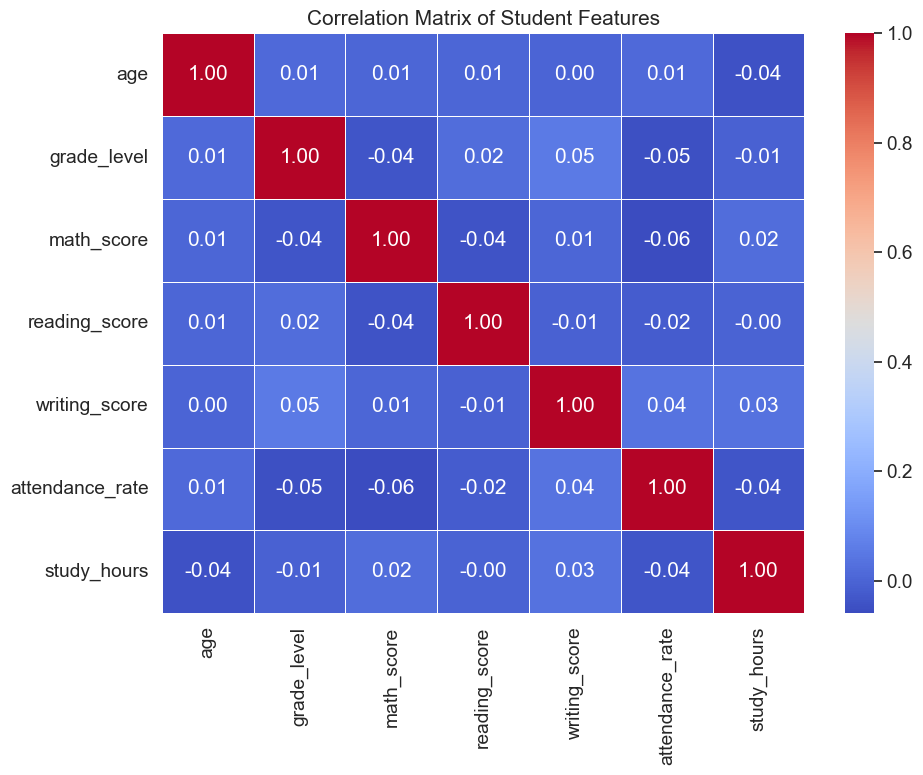

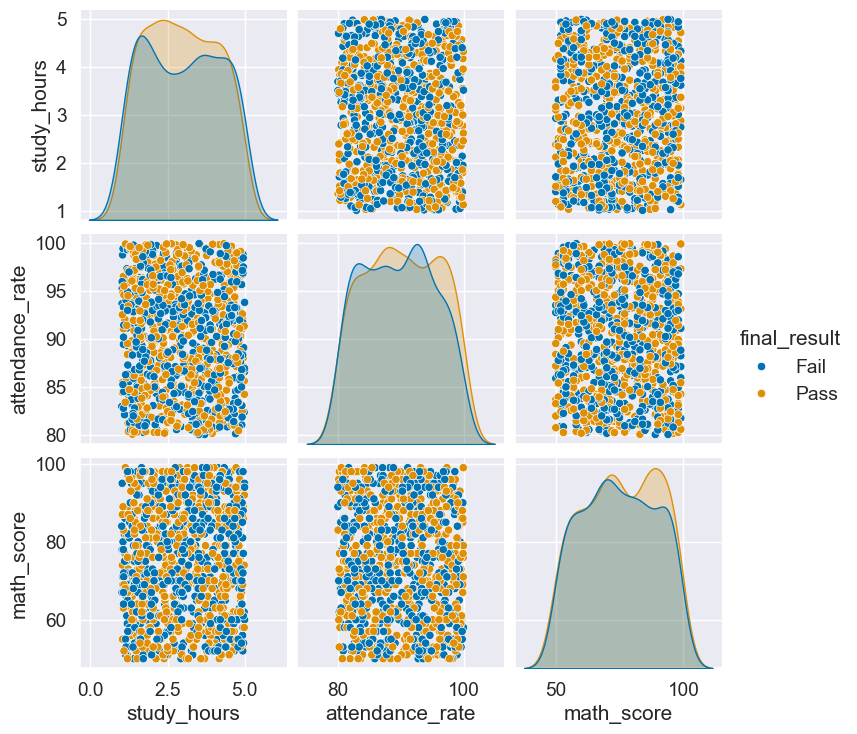

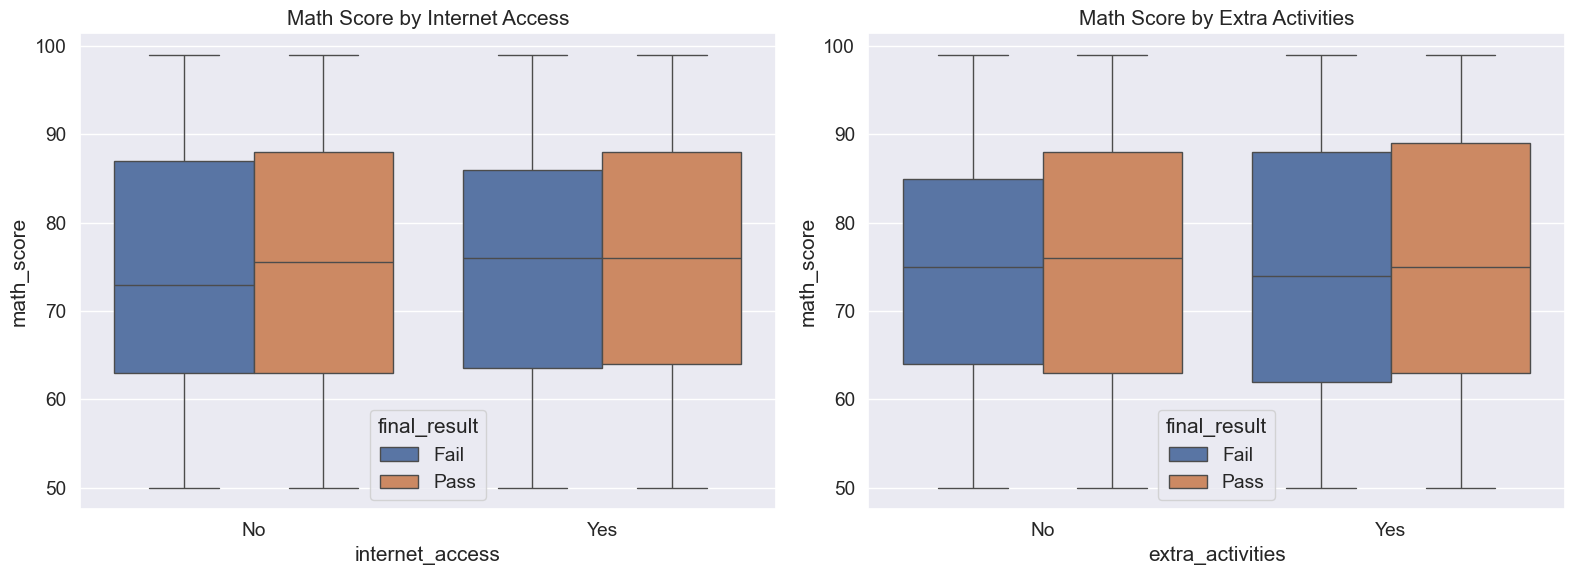

In [12]:
# Identify and visualize relationships between features

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Student Features')
plt.tight_layout()
plt.show()

key_features = ['study_hours', 'attendance_rate', 'math_score', 'final_result']
sns.pairplot(data=df, vars=['study_hours', 'attendance_rate', 'math_score'], hue='final_result', palette='colorblind', height=2.5)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x='internet_access', y='math_score', hue='final_result', ax=axes[0])
axes[0].set_title('Math Score by Internet Access')
sns.boxplot(data=df, x='extra_activities', y='math_score', hue='final_result', ax=axes[1])
axes[1].set_title('Math Score by Extra Activities')
plt.tight_layout()
plt.show()

### Assignment  2: Feature Selection and Data Preparation (20 points) ###
* Select relevant features for clustering
* Standard scale the data as appropriate

In [13]:
# 1. Select relevant features for clustering

categorical_features = ['gender', 'parent_education', 'internet_access', 'lunch_type', 'extra_activities', 'final_result']
numerical_features = ['age', 'grade_level', 'math_score', 'reading_score', 'writing_score', 'attendance_rate', 'study_hours']

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),    
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

mlb_preprocessed = preprocessor.fit_transform(df)

feature_names = list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
new_columns = numerical_features + feature_names
mlb_preprocessed_df = pd.DataFrame(mlb_preprocessed, columns=new_columns)
mlb_preprocessed_df.head()



,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,gender_Female,gender_Male,gender_Other,...,parent_education_Master's,parent_education_PhD,internet_access_No,internet_access_Yes,lunch_type_Free or reduced,lunch_type_Standard,extra_activities_No,extra_activities_Yes,final_result_Fail,final_result_Pass
0,1.225664,-0.416571,-0.081485,-0.929223,1.032118,0.835495,0.978252,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
1,1.225664,1.344829,1.667110,-0.300095,1.101621,0.575667,-0.078714,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,1.225664,-1.297271,-1.130641,-0.999127,1.657644,1.529483,-0.915402,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,1.225664,1.344829,-0.361260,0.958163,-0.427443,1.143005,-1.125466,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,-1.223215,-1.297271,0.687897,0.189228,1.310129,0.253913,-0.554716,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0


In [14]:
# 2. Standard scale the data

mlb_preprocessed_df.head()

,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,gender_Female,gender_Male,gender_Other,...,parent_education_Master's,parent_education_PhD,internet_access_No,internet_access_Yes,lunch_type_Free or reduced,lunch_type_Standard,extra_activities_No,extra_activities_Yes,final_result_Fail,final_result_Pass
0,1.225664,-0.416571,-0.081485,-0.929223,1.032118,0.835495,0.978252,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
1,1.225664,1.344829,1.667110,-0.300095,1.101621,0.575667,-0.078714,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,1.225664,-1.297271,-1.130641,-0.999127,1.657644,1.529483,-0.915402,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,1.225664,1.344829,-0.361260,0.958163,-0.427443,1.143005,-1.125466,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,-1.223215,-1.297271,0.687897,0.189228,1.310129,0.253913,-0.554716,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0


### Assignment 3: *K*-Means Clustering (50 points) ###
* Using Elbow method to determine the optional number of clusters. Plot the WCSS with *k* and determine the elbow point (*k*). 
* Use Silouette score to determine the optimal number of clusters. Plot the Silouette score with *k* and determine the optional *k*.
* Implement the K-Means algorithm and visualize the resulting clusters for each optional *k* in above questions.

c:\Users\LENOVO\anaconda3\envs\data-privacy-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\data-privacy-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\data-privacy-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\data-privacy-env\Lib\site-packages\s

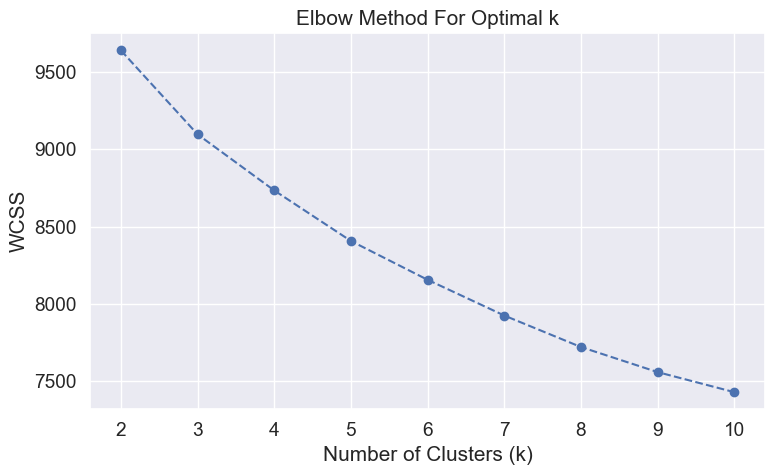

In [15]:
# Using Elbow method to determine the optional number of clusters. Plot the WCSS with *k* and determine the elbow point (*k*).

wcss = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(mlb_preprocessed)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

c:\Users\LENOVO\anaconda3\envs\data-privacy-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\data-privacy-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\data-privacy-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\LENOVO\anaconda3\envs\data-privacy-env\Lib\site-packages\s

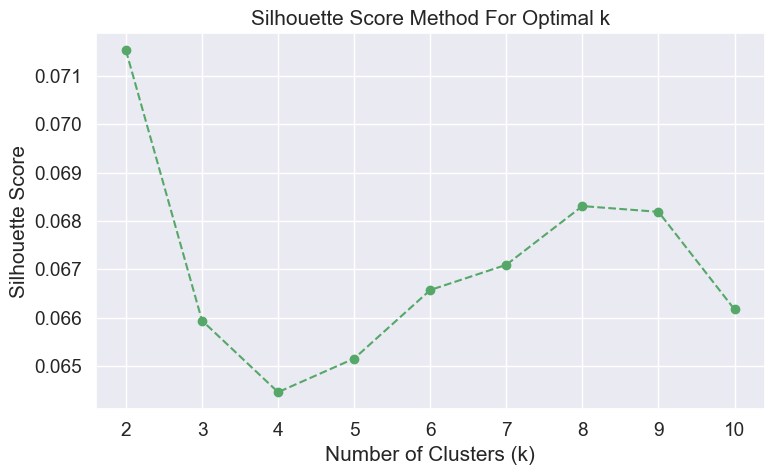

In [16]:
# Use Silouette score to determine the optimal number of clusters. Plot the Silouette score with *k* and determine the optional *k*.

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    cluster_labels = kmeans.fit_predict(mlb_preprocessed)
    score = silhouette_score(mlb_preprocessed, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--', color='g')
plt.title('Silhouette Score Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

c:\Users\LENOVO\anaconda3\envs\data-privacy-env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


For n_clusters = 3 The average silhouette_score is : 0.063

Cluster Centers:
 [[ 1.22443972e-03 -2.87929458e-01 -2.87779407e-01 -1.97399609e-01
   6.92295482e-02  9.57924551e-01 -2.52121163e-01  3.23033708e-01
   3.28651685e-01  3.48314607e-01  2.55617978e-01  2.72471910e-01
   2.19101124e-01  2.52808989e-01  4.85955056e-01  5.14044944e-01
   5.67415730e-01  4.32584270e-01  4.80337079e-01  5.19662921e-01
   4.63483146e-01  5.36516854e-01  3.33066907e-16]
 [-8.37524492e-02 -2.91550526e-01  2.01379649e-01 -7.47283006e-02
  -8.59369054e-01 -6.75218403e-01  3.02772682e-02  3.02839117e-01
   4.00630915e-01  2.96529968e-01  3.09148265e-01  2.17665615e-01
   2.11356467e-01  2.61829653e-01  4.92113565e-01  5.07886435e-01
   4.70031546e-01  5.29968454e-01  4.73186120e-01  5.26813880e-01
   5.17350158e-01  4.82649842e-01  1.00000000e+00]
 [ 7.98581831e-02  5.96099095e-01  1.18079879e-01  2.87349028e-01
   7.57719483e-01 -3.88308583e-01  2.45129175e-01  3.51681957e-01
   3.39449541e-01  3.0886850

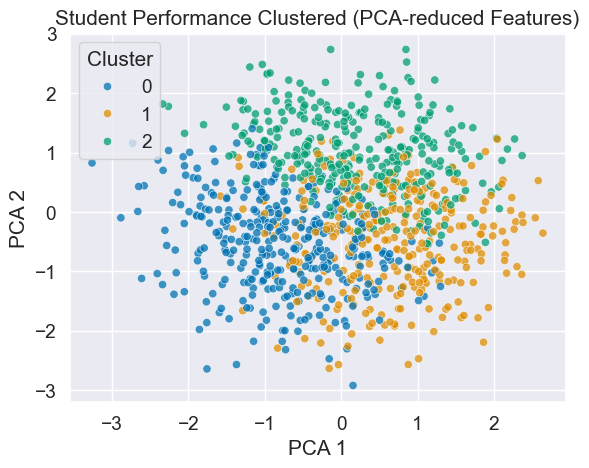

In [18]:
# Implement the K-Means algorithm and visualize the resulting clusters for each optional *k* in above questions.

optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=0)
kmeans.fit(mlb_preprocessed_df)
clusters = kmeans.predict(mlb_preprocessed_df)

mlb_preprocessed_df['Cluster'] = clusters

silhouette_avg = silhouette_score(mlb_preprocessed, clusters)
print("For n_clusters =", optimal_k, f"The average silhouette_score is : {silhouette_avg:.3f}")
print("")

print("Cluster Centers:\n", kmeans.cluster_centers_)

pca = PCA(n_components=2)
mlb_pca = pca.fit_transform(mlb_preprocessed)

sns.scatterplot(x=mlb_pca[:, 0], y=mlb_pca[:, 1], hue=clusters, alpha=0.75, palette="colorblind")
plt.title('Student Performance Clustered (PCA-reduced Features)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()